In [ ]:
# nb iteration a 20

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model, loss function, and optimizer
model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
def train_model(model, train_loader, criterion, optimizer, epochs=1):
    model.train()
    for epoch in range(epochs):
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

train_model(model, train_loader, criterion, optimizer, epochs=1)

# Test the model accuracy
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    print(f'Accuracy: {100 * correct / total:.2f}%')

test_model(model, test_loader)

# PGD attack
def pgd_attack(model, images, labels, epsilon=0.3, alpha=0.01, num_iter=20):
    images = images.clone().detach().to(torch.float).requires_grad_(True)
    original_images = images.data

    for _ in range(num_iter):
        outputs = model(images)
        model.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()

        # PGD update step
        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        images = torch.clamp(original_images + eta, min=0, max=1).detach_()
        images.requires_grad = True

    return images

# Evaluate the model under PGD attack
def evaluate_under_attack(model, test_loader, epsilon=0.3):
    model.eval()
    correct = 0
    total = 0
    for data, target in test_loader:
        adv_data = pgd_attack(model, data, target, epsilon=epsilon)
        output = model(adv_data)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

    print(f'Accuracy under PGD attack (ε={epsilon}): {100 * correct / total:.2f}%')

# Evaluate the model under PGD attack
evaluate_under_attack(model, test_loader, epsilon=0.3)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:01<00:00, 8164104.68it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 1633393.03it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



...

100%|██████████| 1648877/1648877 [00:00<00:00, 13560119.36it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 3279485.07it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Epoch [1/1], Loss: 0.0970
Accuracy: 98.12%
Accuracy under PGD attack (ε=0.3): 15.67%


Original Prediction: 7  Perturbed Prediction: 2 Label: 7


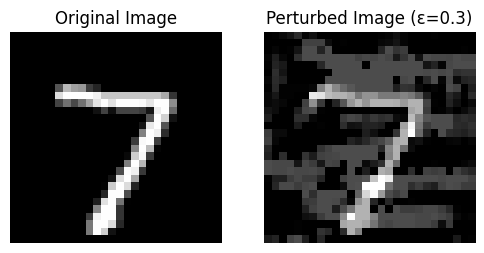

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Function to show images
def imshow(img, title=None):
    img = img.detach().squeeze().cpu().numpy()  # Detach from graph, then convert to NumPy array
    plt.imshow(img, cmap='gray')  # MNIST is grayscale, so we use cmap='gray'
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Display original and perturbed images
def show_original_and_perturbed(model, test_loader, epsilon=0.3):
    model.eval()
    for data, target in test_loader:
        # Get the first image and label in the batch
        original_img = data[0].unsqueeze(0)  # Take the first image and add a batch dimension
        label = target[0]

        # Create adversarial example using PGD
        adv_img = pgd_attack(model, original_img, label.unsqueeze(0), epsilon=epsilon)


        output = model(original_img)
        _, origin_pred = torch.max(output.data, 1)


        output = model(adv_img)
        _, adv_pred = torch.max(output.data, 1)

        print('Original Prediction:', origin_pred.item(), ' Perturbed Prediction:', adv_pred.item(), 'Label:', label.item())

        # Plot original and perturbed images side by side
        plt.figure(figsize=(6, 3))

        # Show original image
        plt.subplot(1, 2, 1)
        imshow(original_img.squeeze(), title='Original Image')  # Squeeze to remove unnecessary dimensions

        # Show perturbed image
        plt.subplot(1, 2, 2)
        imshow(adv_img.squeeze(), title=f'Perturbed Image (ε={epsilon})')

        plt.show()
        break  # We only need to show the first example

# Example PGD attack function (same as before)
def pgd_attack(model, images, labels, epsilon=0.3, alpha=0.01, num_iter=30):
    images = images.clone().detach().to(torch.float).requires_grad_(True)
    original_images = images.data

    for _ in range(num_iter):
        outputs = model(images)
        model.zero_grad()
        loss = F.cross_entropy(outputs, labels)
        loss.backward()

        # PGD update step
        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        images = torch.clamp(original_images + eta, min=0, max=1).detach_()
        images.requires_grad = True

    return images

# Assuming the model and test_loader are defined and loaded with the correct MNIST data:
show_original_and_perturbed(model, test_loader, epsilon=0.3)
